## Telco Costumer Churn

> https://www.kaggle.com/datasets/blastchar/telco-customer-churn

     Autora do Notebook: Isabella Heder 

Este case tem como objetivo prever o comportamento dos clientes de uma empresa de telecomunicações (Telco) para identificar quais possuem maior probabilidade de cancelar seus serviços (churn). Com base nessa análise, é possível desenvolver estratégias direcionadas de retenção de clientes, aumentando o valor ao longo do tempo (LTV) e reduzindo perdas de receita.

#### **Objetivo**
Criar modelos analíticos que permitam:
- Identificar clientes com risco de churn
- Entender os principais fatores que influenciam o cancelamento
- Apoiar a definição de programas de retenção mais eficientes e personalizados

##### Variável alvo (target)
- **Churn**: indica se o cliente cancelou o serviço no último mês

In [36]:
import pandas as pd
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 300)  
pd.set_option('display.max_colwidth', None)  

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [37]:
df = pd.read_csv('dataset-telco.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
df.duplicated().sum()

np.int64(0)

- df não tem valores nulos
- df não tem linhas duplicadas

#### Dicionário de Dados 

Cada linha do dataset representa um cliente e cada coluna contém atributos relacionados a esse cliente.

| Coluna            | Tipo de Dado   | Descrição                                                                 |
|------------------|----------------|---------------------------------------------------------------------------|
| customerID       | String         | Identificador único do cliente                                           |
| gender           | Categórico     | Gênero do cliente (Male, Female)                                         |
| SeniorCitizen    | Binário (0/1)  | Indica se o cliente é idoso (1 = sim, 0 = não)                           |
| Partner          | Categórico     | Indica se o cliente possui parceiro(a) (Yes/No)                          |
| Dependents       | Categórico     | Indica se o cliente possui dependentes (Yes/No)                          |
| tenure           | Numérico       | Tempo de permanência do cliente na empresa (em meses)                    |
| PhoneService     | Categórico     | Indica se o cliente possui serviço de telefone (Yes/No)                  |
| MultipleLines    | Categórico     | Indica se o cliente possui múltiplas linhas telefônicas                  |
| InternetService  | Categórico     | Tipo de serviço de internet (DSL, Fiber optic, No)                       |
| OnlineSecurity   | Categórico     | Indica se o cliente possui segurança online                              |
| OnlineBackup     | Categórico     | Indica se o cliente possui backup online                                 |
| DeviceProtection | Categórico     | Indica se o cliente possui proteção de dispositivo                       |
| TechSupport      | Categórico     | Indica se o cliente possui suporte técnico                               |
| StreamingTV      | Categórico     | Indica se o cliente possui streaming de TV                               |
| StreamingMovies  | Categórico     | Indica se o cliente possui streaming de filmes                           |
| Contract         | Categórico     | Tipo de contrato (Month-to-month, One year, Two year)                    |
| PaperlessBilling | Categórico     | Indica se o cliente utiliza faturamento digital                          |
| PaymentMethod    | Categórico     | Método de pagamento (Electronic check, Credit card, etc.)                |
| MonthlyCharges   | Numérico       | Valor mensal pago pelo cliente                                           |
| TotalCharges     | Numérico (mas está como object)    | Valor total pago pelo cliente ao longo do tempo                          |
| Churn            | Categórico     | Variável alvo: indica se o cliente cancelou (Yes/No)                     |

In [39]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


     Transformando TotalCharges em valor numérico 

In [40]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

np.int64(11)

Os nulos criados a partir da transformação serão retirados (porque prefiro tratar nulos dessa maneira ao invés de imputar valores)

In [41]:
df = df.dropna(subset=['TotalCharges'])

_______________
### Distribuição das Variáveis

In [42]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7032,7032,7032.000000,7032,7032,7032.000000,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032.000000,7032.000000,7032
unique,7032,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3549,NaN,3639,4933,NaN,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,NaN,NaN,5163
mean,NaN,NaN,0.162400,NaN,NaN,32.421786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.798208,2283.300441,NaN
std,NaN,NaN,0.368844,NaN,NaN,24.545260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.085974,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.587500,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.862500,3794.737500,NaN


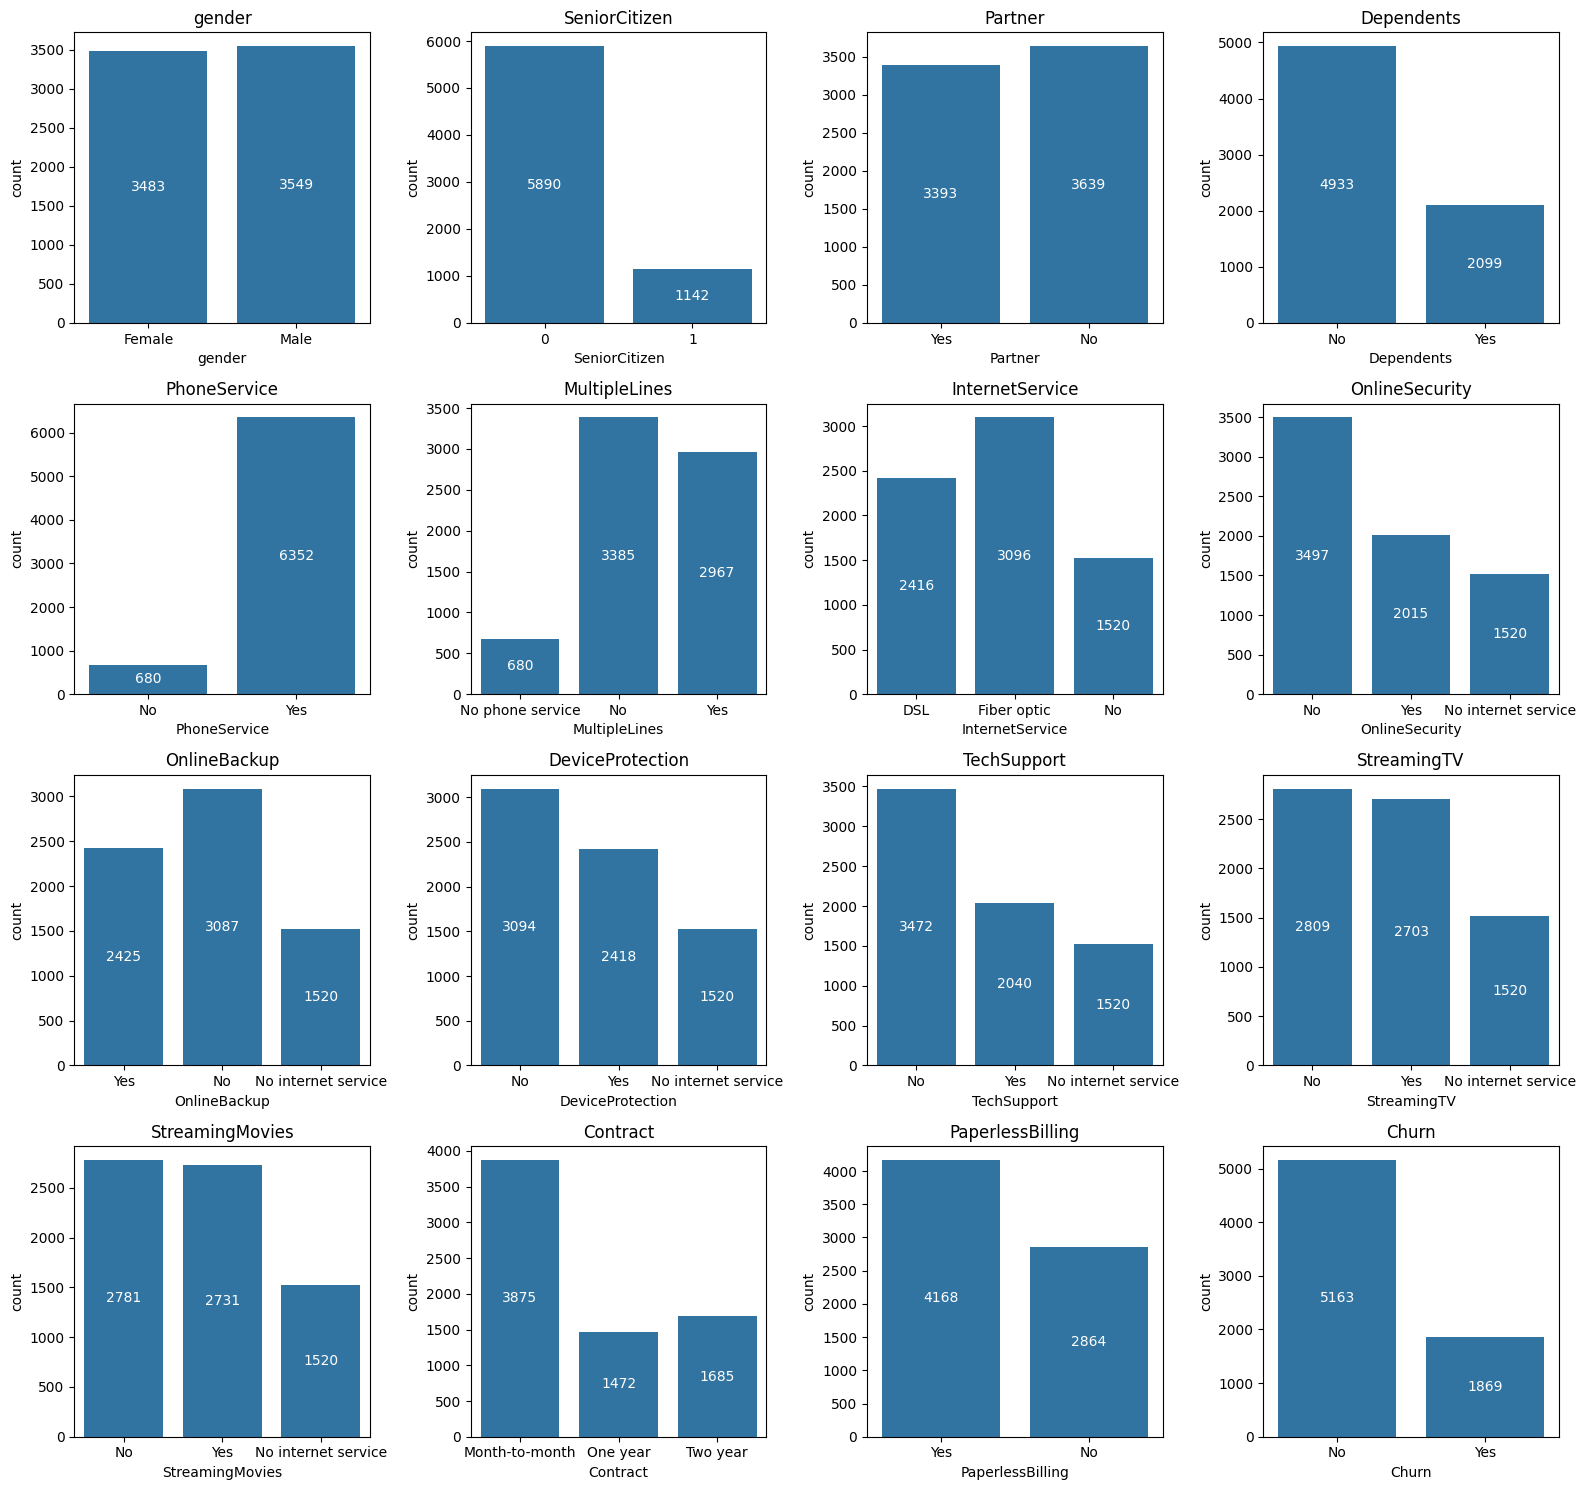

In [43]:
variaveis = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
    'PaperlessBilling', 'Churn']

plt.figure(figsize=(16, 15))
for i, col in enumerate(variaveis, 1):
    ax = plt.subplot(4, 4, i)
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fmt='%d', color='white')

plt.tight_layout()
plt.show()

In [44]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

Interpretação:

- gender: bem distribuído, provavelmente sem viés por gênero
- SeniorCitizen: base majoritariamente composta por clientes não idosos
- partner: bem distribuído
- dependents: maioria dos clientes não possuem dependentes
- phone service: a grande maioria dos clientes possuem
- multiple lines: quantidade de linhas bem distribuída (entre os clientes que tem linha)
- internet service: fiber optic é o mais comum
- serviços adicionais: a maioria dos clientes não possuem serviços adicionais
  - OnlineSecurity: maioria não possui
  - OnlineBackup: maioria não possui
  - DeviceProtection: maioria não possui
  - TechSupport: maioria não possui 
- serviços de entretenimento: distribuição equilibrada entre yes e no (StreamingTV e StreamingMovies)
- contract: a maioria dos clientes tem contrato month-to-month (maior flexibilidade e liberdade --> talvez relação com churn?)
- paperless billing: a maioria dos clientes usa faturas digitais
- churn: desbalanceado
- payment method: a maioria compra com cheque, fora isso as outras opções estão equilibradas


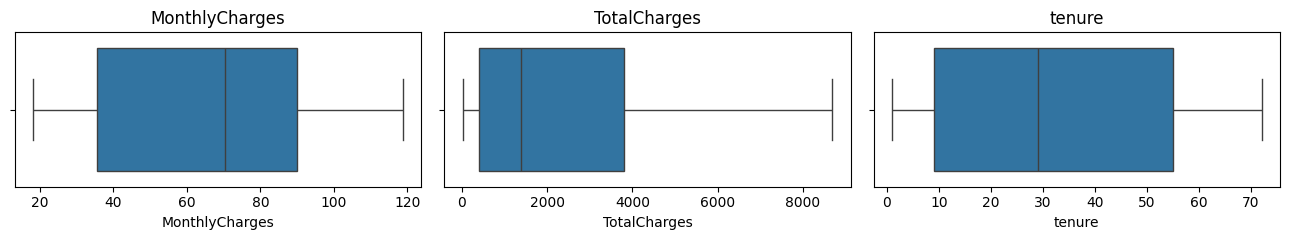

In [45]:
variaveis_continuas = ['MonthlyCharges', 'TotalCharges', 'tenure']
plt.figure(figsize=(13, 2.5))

for i, col in enumerate(variaveis_continuas):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

Interpretação:
- em geral os dados estão bem espalhados
- TotalCharges apresenta forte assimetria a direita, com uma cauda longa (mas sem outliers)
_________

### Categoria nova (has_Internet)

- muitas colunas de serviço tem a categoria "No internet service"
- essa categoria pode ser transformada em uma nova coluna 
- e depois "No internet service" --> "No" (facilitando inclusive a transformação de colunas cat em binárias)

In [46]:
df['has_internet'] = df['InternetService'].apply(lambda x: 0 if x == 'No' else 1)

Transformando todas os valores de "No Internet Service" em "No"

In [47]:
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
        'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols:
    df[col] = df[col].replace('No internet service', 'No')

for col in cols:
    df[col] = df[col].replace({
        'No internet service': 0,
        'No': 0,
        'Yes': 1 })

C:\Users\IsabellaHeder\AppData\Local\Temp\ipykernel_28420\3714653123.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


______________________
#### Relação de Categorias com Churn

In [48]:
cols = ['SeniorCitizen', 'Contract', 'Dependents', 'Partner', 'OnlineSecurity', 'TechSupport']

for col in cols:
    print(pd.crosstab(df[col], df['Churn'], normalize='index'), '\n')

Churn                No       Yes
SeniorCitizen                    
0              0.763497  0.236503
1              0.583187  0.416813 

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487 

Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312 

Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171 

Churn                 No       Yes
OnlineSecurity                    
0               0.686267  0.313733
1               0.853598  0.146402 

Churn              No       Yes
TechSupport                    
0            0.687700  0.312300
1            0.848039  0.151961 



Interpretação:
- clientes idosos tem quase o dobro de churn em relação aos não idosos
- clientes com contrato mensal tem churn alto, enquanto contratos longos praticamente eliminam churn
- clientes sem dependentes churnam o dobro do que clientes com dependentes
- clientes com partner churnam menos do que clientes sem partner

     Verificando a relação de Churn com Número de Serviços 

Hipótese: quanto mais serviços --> menor churn

In [49]:
colunas_servico = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies']

df['numero_servicos'] = df[colunas_servico].apply(lambda x: (x == 'Yes').sum(), axis=1)

In [50]:
churn_servicos = pd.crosstab(df['numero_servicos'], df['Churn'], normalize='index')
print((churn_servicos * 100).round(2))

Churn               No    Yes
numero_servicos              
0                75.00  25.00
1                74.92  25.08
2                71.35  28.65


Conclusão:
- quanto mais serviços, menor o churn (mas depende em qual nível de serviços o cliente está)
- cliente sem serviços representam o maior churn
- clientes com 2 e 3 serviços apresentam churn mais alto que clientes com 1 serviço
    - teoria: cliente começa a usar -> experimenta -> não vê valor -> churn
- clientes com 4-6 serviços caem na proporção de churn
- clientes com 7 e 8 serviços tem taxa de churn super baixa
_____

### Correlação com Heatmap
     Transformando variáveis binárias (Yes, No) em (0, 1) 

In [51]:
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})
df['Partner'] = df['Partner'].map({'No': 0, 'Yes': 1})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No': 0, 'Yes': 1})
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1})

In [52]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

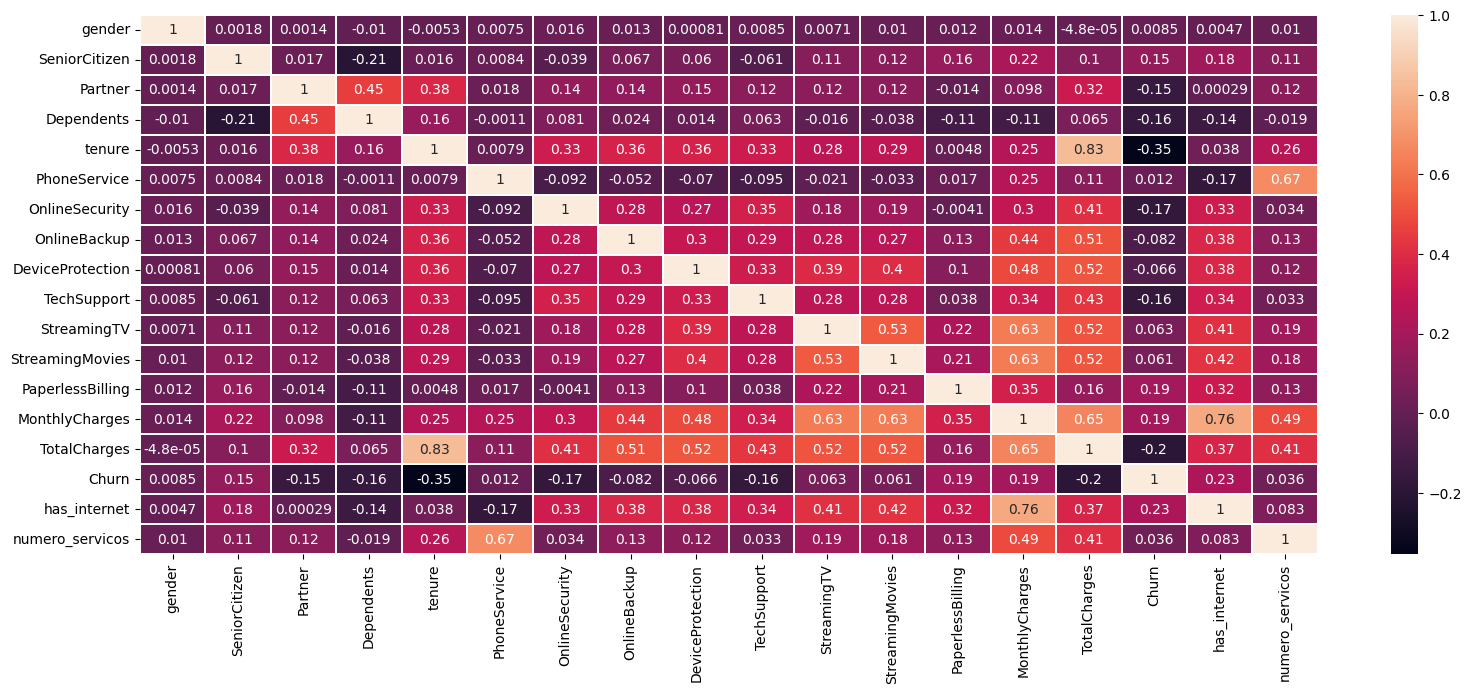

In [53]:
matriz_correlacao = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(19, 7))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2)
plt.show()

Relações com a Target (Churn):
- Correlação mais forte (-0.35 tenure) indica que clientes com maior tempo de contrato têm menor probabilidade de churn
- has_internet (0.23) indica que clientes com serviço de internet tem maior probabilidade de churn
- Monthly Charges (0.19) indica que clientes que pagam mais mensalmente tendem a churnar mais
- Total Charges (-0.2) indica que clientes que acumularam mais gastos ao longo do tempo tendem a churnar menos
- Partner (-0.15) e Dependents (-0.16) indicam que clientes que vinculam com sua família tendem a churnar  menos
- Senior Citizen (0.15): clientes idosos tendem a churnar mais

Relações entre variáveis:
- tenure × TotalCharges (0.83): esperado porque total charges é acumulado ao longo do tempo
- MonthlyCharges × TotalCharges (0.65): relação direta entre gasto mensal e gasto total
- Partner × Dependents (0.45): indica que clientes com parceiro tendem a ter dependentes

_____________
### Feature Engineering

In [54]:
df.drop(columns=['customerID'], inplace=True)

In [55]:
colunas_dummy = [
    'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

df2 = pd.get_dummies(df, columns=colunas_dummy, drop_first=True)

In [56]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   OnlineSecurity                         7032 non-null   int64  
 7   OnlineBackup                           7032 non-null   int64  
 8   DeviceProtection                       7032 non-null   int64  
 9   TechSupport                            7032 non-null   int64  
 10  StreamingTV                            7032 non-null   int64  
 11  Streaming

     Média do Custo 

In [57]:
df2['media_custo'] = df['TotalCharges'] / (df['tenure'] + 1)

     Flag de alto risco 

In [58]:
df2['alto_risco'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['tenure'] < 12) &
    (df2['InternetService_Fiber optic'] == 1) &
    (df['numero_servicos'] <= 2)).astype(int)

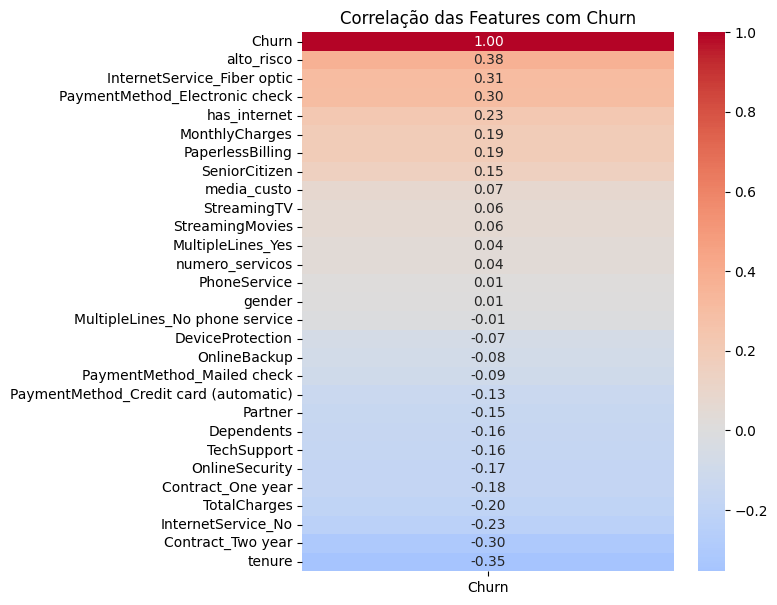

In [59]:
corr = df2.corr()
plt.figure(figsize=(6, 7))

corr_churn = corr[['Churn']].sort_values(by='Churn', ascending=False)
sns.heatmap(corr_churn, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlação das Features com Churn')
plt.show()

- Clientes com fibra têm maior churn (0.31)
- Clientes que pagam com Electronic check (0.30) tem maior churn
- feature nova: alto_risco (0.38) mostrou boa capacidade de segmentação
- PaperlessBilling (0.19): clientes digitais churnam mais
- tenure (-0.35): clientes novos são o maior risco
- Contract_Two year (-0.30): contratos longos protegem contra churn
- InternetService_No (-0.23): quem não tem internet churna menos
- Serviços adicionais reduzem churn (OnlineSecurity e TechSupport)

In [60]:
from sklearn.metrics import precision_score, accuracy_score, confusion_matrix, roc_auc_score, recall_score, classification_report

def avaliar_modelo(y_test, y_pred):
    print(f"acuracia: {accuracy_score(y_test, y_pred)}")
    print(f"precisao: {precision_score(y_test, y_pred)}")
    print(f"recall: {recall_score(y_test, y_pred)}")
    cm = confusion_matrix(y_test, y_pred)
    print(f"roc auc: {roc_auc_score(y_test, y_pred)}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

### Modelo

``Undersampling``

In [61]:
# tamanho da menor classe
min_class_size = df2['Churn'].value_counts().min()
# undersampling
df2_under = (
    df2.groupby('Churn')
       .sample(n=min_class_size, random_state=42)
       .reset_index(drop=True)
)
# conferindo
print(df2_under['Churn'].value_counts())

Churn
0    1869
1    1869
Name: count, dtype: int64


In [62]:
colunas_dropar = [
    'gender',
    'MultipleLines_No phone service']

X = df2_under.drop(['Churn'] + colunas_dropar, axis=1)
y = df2_under['Churn']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

     Logistic Regression 

acuracia: 0.7794117647058824
precisao: 0.7580246913580246
recall: 0.820855614973262
roc auc: 0.7794117647058824


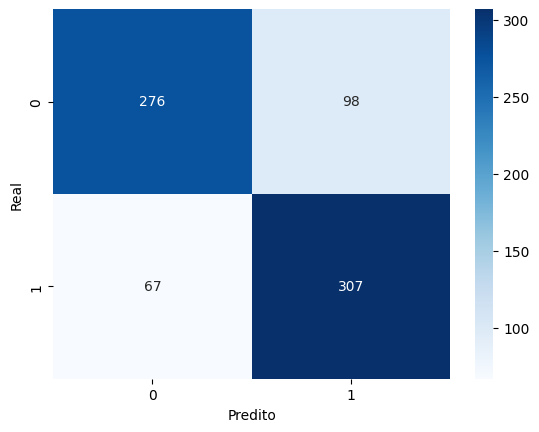

In [64]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000, class_weight='balanced')

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

avaliar_modelo(y_test, y_pred)

       Random Forest 

acuracia: 0.7112299465240641
precisao: 0.6436363636363637
recall: 0.946524064171123
roc auc: 0.7112299465240641


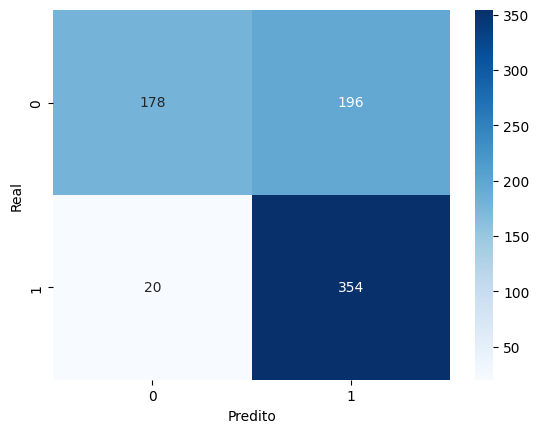

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

threshold = 0.25
y_pred_rf = (y_proba_rf >= threshold).astype(int)

avaliar_modelo(y_test, y_pred_rf)

     XGBoost 

acuracia: 0.766042780748663
precisao: 0.7420924574209246
recall: 0.8155080213903744
roc auc: 0.766042780748663


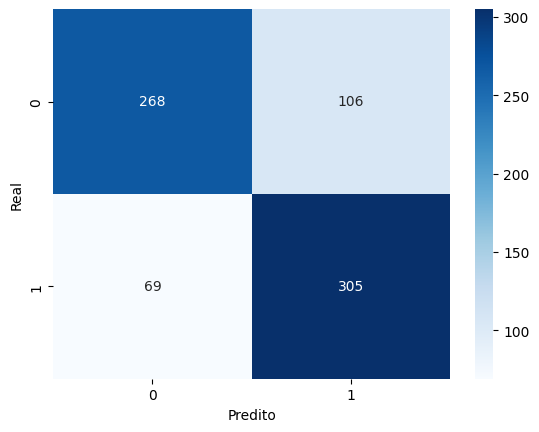

In [66]:
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42, 
    scale_pos_weight=scale_pos_weight)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

avaliar_modelo(y_test, y_pred_xgb)

     Gradient Boosting 

acuracia: 0.7727272727272727
precisao: 0.7475728155339806
recall: 0.8235294117647058
roc auc: 0.7727272727272727


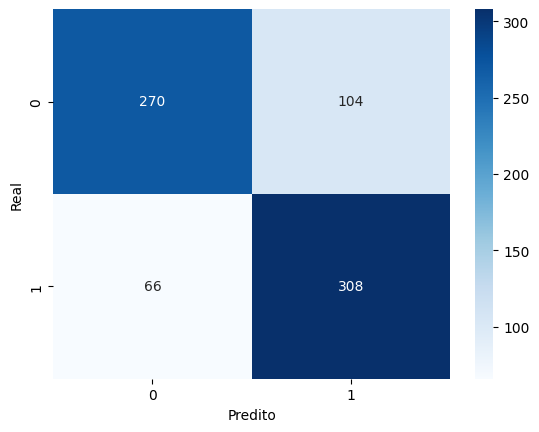

In [71]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)

gb.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

avaliar_modelo(y_test, y_pred_gb)

In [72]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.80      0.72      0.76       374
           1       0.75      0.82      0.78       374

    accuracy                           0.77       748
   macro avg       0.78      0.77      0.77       748
weighted avg       0.78      0.77      0.77       748



## Conclusão:
O modelo de **Gradient Boosting** apresentou o melhor desempenho geral e foi selecionado como modelo final por oferecer o melhor trade-off entre performance e capacidade preditiva.

#### Comparação dos Modelos

| Modelo                         | Acurácia | Precisão | Recall | ROC AUC | Comentário |
|--------------------------------|---------|---------|--------|---------|------------|
| Logistic Regression            | 0.77    | 0.75    | 0.82   | 0.77    | Alto recall, melhor para identificar churn |
| Random Forest                  | 0.73      | 0.72      | 0.75     | 0.73      | Modelo bom, mas perde muitos churns |
| Random Forest (threshold = 0.25)  | 0.71      | 0.64      | 0.94     | 0.71      | Melhor recall, mas perde em falsos positivos |
| XGBoost                        | 0.76    | 0.74    | 0.81   | 0.76    | Modelo equilibrado, bom trade-off |
| Gradient Boosting    | 0.77    | 0.74    | 0.82   | 0.77 | Melhor modelo geral (equilíbrio entre recall e AUC) |

Os modelos Logistic Regression e Gradient Boosting apresentaram performance bem parecida. No entanto, por conta do melhor equilíbrio entre precisão e recall (por pouquíssima diferença), eu ``escolhi o Gradient Boosting``



| Modelo                         | TP | TN |
|--------------------------------|----|----|
| Logistic Regression            | 307 | 276 |
| Gradient Boosting | 308 | 270 |

Obrigada!